# Intro to Pandas

In [2]:
#!pip install pandas

In [3]:
import pandas as pd

## Core Data structure

`pandas` library introduces two new data structures: `Series` and `DataFrame`.

### Pandas series

A Series in a one-dimensional object (similar to an array, list, or column in a table). A labeled index is assigned to each item in the Series (the default are 0-N indeces, being N the length of the Series minus one).

In [4]:
# Create a series from a list
s = pd.Series([7, "Hello world", 42.26, True, "Falsissimo"])

print(f"Series with default index: \n{s}")

Series with default index: 
0              7
1    Hello world
2          42.26
3           True
4     Falsissimo
dtype: object


In [5]:
# Create a series with a user-defined index
series_with_index = pd.Series([2, True, "Hey", 3.14], index=["A", "B", "C", "Ciao"])

print(f"\nSeries with user-defined index: \n{series_with_index}")


Series with user-defined index: 
A          2
B       True
C        Hey
Ciao    3.14
dtype: object


In [6]:
# Algebraic operations
s = pd.Series([1, 2, 3], index=["A", "B", "C"])

print(f"\ns + 10: \n{s + 10}")
print(f"\ns*2: \n{s*2}")


s + 10: 
A    11
B    12
C    13
dtype: int64

s*2: 
A    2
B    4
C    6
dtype: int64


In [7]:
s = pd.Series([1, 2, 3], index=["A", "B", "C"])

# Access to an indexed series
print(f"Element at the index 0 of s: {s["A"]}")
print(f"Element at the index 'Ciao': {series_with_index["Ciao"]}")

# Access to more element in one time
intreresting_elements = ["A", "B"]
print(f"Intreresting elements of s \n{s[intreresting_elements]}")

Element at the index 0 of s: 1
Element at the index 'Ciao': 3.14
Intreresting elements of s 
A    1
B    2
dtype: int64


In [8]:
# Reduction operations (sum, mean, max, etc...)
s = pd.Series([1, 2, 3], index=["A", "B", "C"])

s.sum()

np.int64(6)

In [9]:
# It is also possible to build a series from a dictionary. In that case the index will be the key. 
cities = {
    "Chicago": 1000,
    "New York": 1300,
    "Portland": 900,
    "San Francisco": 1100,
    "Austin": 450,
    "Boston": None,
}
cities = pd.Series(cities)

print(f"\nCities Series: \n{cities}")


Cities Series: 
Chicago          1000.0
New York         1300.0
Portland          900.0
San Francisco    1100.0
Austin            450.0
Boston              NaN
dtype: float64


In [10]:
# Like in R, it is possible to work with boolan masks
cities > 0

Chicago           True
New York          True
Portland          True
San Francisco     True
Austin            True
Boston           False
dtype: bool

In [11]:
cities[cities > 1000]

New York         1300.0
San Francisco    1100.0
dtype: float64

## Pandas DataFrame

A `DataFrame` is a tabular data structure comprised of rows and columns. It can be thought of as a group of Series objects that share an index (the columns' name).

In order to create manually a DataFrame we can pass a dictionary of lists to the DataFrame constructor:

In [12]:
data = {
    "letters": ["A", "B", "C", "D"],
    "numbers": [1, 2, 3, 4],
    "spelling": ["One", "Two", "Three", "Four"],
}

letters_numbers = pd.DataFrame(data, columns=["letters", "numbers", "spelling"])
print(letters_numbers)

  letters  numbers spelling
0       A        1      One
1       B        2      Two
2       C        3    Three
3       D        4     Four


More often we have a dataset that we want to read into a DataFrame. With pandas it's possible to load data stored in many formats, but the most common is probably CSV Yuo can use the read_csv function to do it, passing the location of the file (it works also with links to web resources!)

In [13]:
# import csv dataset
path_csv = "https://raw.githubusercontent.com/LorenzoTonet/Intro_to_ML_26-27/refs/heads/main/data/ign.csv"
#path_csv = "path local file"
reviews = pd.read_csv(path_csv, index_col=0)
reviews.head(5)

,score_phrase,title,url,platform,score,genre,editors_choice,release_year,release_month,release_day
0,Amazing,LittleBigPlanet PS Vita,/games/littlebigplanet-vita/vita-98907,PlayStation Vita,9.0,Platformer,Y,2012,9,12
1,Amazing,LittleBigPlanet PS Vita -- Marvel Super Hero E...,/games/littlebigplanet-ps-vita-marvel-super-he...,PlayStation Vita,9.0,Platformer,Y,2012,9,12
2,Great,Splice: Tree of Life,/games/splice/ipad-141070,iPad,8.5,Puzzle,N,2012,9,12
3,Great,NHL 13,/games/nhl-13/xbox-360-128182,Xbox 360,8.5,Sports,N,2012,9,11
4,Great,NHL 13,/games/nhl-13/ps3-128181,PlayStation 3,8.5,Sports,N,2012,9,11


### Indexing

`pandas` supports several methods for indexing data in a table:
- `iloc` (integer based indexing): refers to rows and columns by their position, expressed as an integer starting from zero;
- `loc` (label based indexing): uses row and column name;
- Boolean indexing: uses boolean masks. Row names are stored in the field index of a data frame, columns names are stored in the field columns.

In [14]:
# Selection of a subset of rows and columns of the dataframe
print(reviews.iloc[0:10, 0:2])  # first ten rows, first two columns (THE LAST INDEX IS NOT INCLUDED)

  score_phrase                                              title
0      Amazing                            LittleBigPlanet PS Vita
1      Amazing  LittleBigPlanet PS Vita -- Marvel Super Hero E...
2        Great                               Splice: Tree of Life
3        Great                                             NHL 13
4        Great                                             NHL 13
5         Good                          Total War Battles: Shogun
6        Awful                                Double Dragon: Neon
7      Amazing                                       Guild Wars 2
8        Awful                                Double Dragon: Neon
9         Good                          Total War Battles: Shogun


In [15]:
# Selection of a subset of rows and columns using columns' names
reviews.loc[0:10, ["title", "score"]]

,title,score
0,LittleBigPlanet PS Vita,9.0
1,LittleBigPlanet PS Vita -- Marvel Super Hero E...,9.0
2,Splice: Tree of Life,8.5
3,NHL 13,8.5
4,NHL 13,8.5
5,Total War Battles: Shogun,7.0
6,Double Dragon: Neon,3.0
7,Guild Wars 2,9.0
8,Double Dragon: Neon,3.0
9,Total War Battles: Shogun,7.0


In [16]:
# Extract a Series from a DataFrame
scores = reviews["score"]
print(scores)
type(scores)

0         9.0
1         9.0
2         8.5
3         8.5
4         8.5
         ... 
18620     7.6
18621     9.0
18622     5.8
18623    10.0
18624    10.0
Name: score, Length: 18625, dtype: float64


pandas.Series

In [17]:
# Indexing using boolean masks
mask = reviews["score"] >= 9.5

# Retrieval of title of the games with a score >=9.5
cool_games = reviews[mask]["title"]
print(cool_games)

33                   Pokemon White Version 2
35                   Pokemon Black Version 2
52       The World Ends with You: Solo Remix
54       The World Ends with You: Solo Remix
135        Zero Escape: Virtue's Last Reward
                        ...                 
18511                                 Inside
18562                Odin Sphere Leifthrasir
18563                Odin Sphere Leifthrasir
18623                                 Inside
18624                                 Inside
Name: title, Length: 385, dtype: str


## Some visuals

In [18]:
#!pip install matplotlib

In [19]:
import matplotlib.pyplot as plt

Text(0, 0.5, 'Frequency')

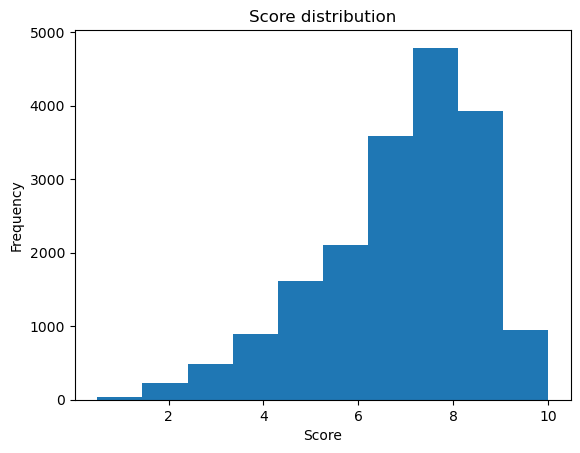

In [20]:
# histogram
plt.title('Score distribution')
_ = plt.hist(reviews["score"])
plt.xlabel('Score')
plt.ylabel('Frequency')

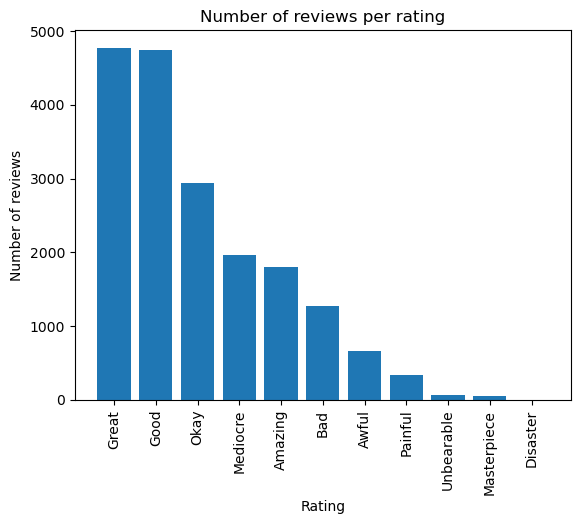

In [21]:
counts_per_genre = reviews['score_phrase'].value_counts()
plt.bar(counts_per_genre.index, counts_per_genre)
plt.xticks(rotation=90)

# We can add the title and the labels of the axes
plt.title('Number of reviews per rating')
plt.xlabel('Rating')
_ = plt.ylabel('Number of reviews')

Just for curiosity...

In [22]:
mask = reviews["score_phrase"] == "Disaster"
reviews[mask]

,score_phrase,title,url,platform,score,genre,editors_choice,release_year,release_month,release_day
890,Disaster,Extreme PaintBrawl,/games/extreme-paintbrawl/pc-10455,PC,0.7,Action,N,1998,10,29
5242,Disaster,Looney Tunes: Back in Action: Zany Race,/games/looney-tunes-back-in-action-zany-race/c...,Wireless,0.5,Racing,N,2003,10,28
12513,Disaster,Action Girlz Racing,/games/action-girlz-racing/wii-889218,Wii,0.8,Racing,N,2009,2,11


---

If you want to learn more about **Pandas**, check out [this link](https://en.wikipedia.org/wiki/Giant_panda) or have a look at the [official documentation](https://pandas.pydata.org/docs/).


---